### Problem 1: Portfolio Construction & Daily Returns

Returns Matrix:
        RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613

Units purchased: [ 89.28571429 172.4137931  156.25       480.76923077]


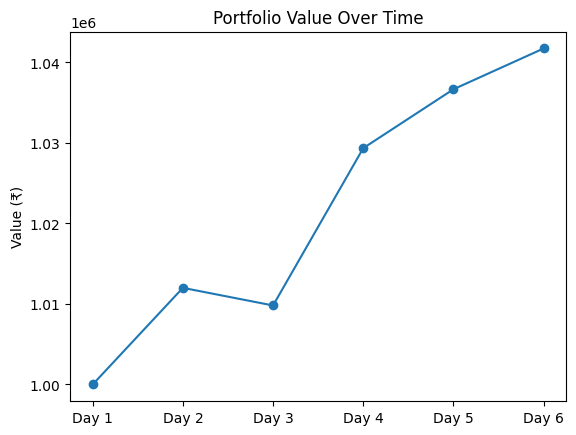


Annualised Volatility: 0.1275 (or 12.75%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# a) Create DataFrame and compute daily returns
data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
prices_df = pd.DataFrame(data, index=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6'])
returns_matrix = prices_df.pct_change().dropna()
print("Returns Matrix:\n", returns_matrix)

# b) Compute units on Day 1 and plot portfolio value
capital = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])
day1_prices = prices_df.iloc[0].values

# Units = amount of money per stock / price of stock
units = (capital * weights) / day1_prices
print("\nUnits purchased:", units)

# Vectorised portfolio value (Price matrix dot product with units vector)
daily_portfolio_values = prices_df.dot(units)

daily_portfolio_values.plot(title='Portfolio Value Over Time', marker='o')
plt.ylabel('Value (₹)')
plt.show()

# c) Annualised volatility
port_returns = daily_portfolio_values.pct_change().dropna()
daily_vol = port_returns.std()
annual_vol = daily_vol * np.sqrt(252)
print(f"\nAnnualised Volatility: {annual_vol:.4f} (or {annual_vol*100:.2f}%)")

### Problem 2: Risk Metrics (VaR, CVaR, MaxDD)

VaR (95%): -0.0252 -> We are 95% confident the daily loss won't exceed 2.52%
VaR (99%): -0.0281 -> We are 99% confident the daily loss won't exceed 2.81%
CVaR (95%): -0.0272
CVaR (99%): -0.0284
Maximum Drawdown: 0.1816 (or 18.16%)


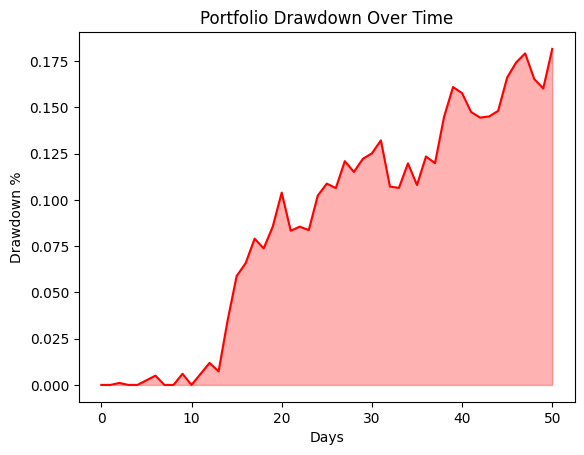

In [ ]:
# Generate 50 simulated days
np.random.seed(42)
sim_returns = np.random.normal(0.001, 0.015, 50)

# Create simulated prices starting at 10,00,000
sim_prices = 1000000 * np.cumprod(1 + sim_returns)
sim_prices = np.insert(sim_prices, 0, 1000000) # Add day 0

# a) Historical VaR
var_95 = np.percentile(sim_returns, 5)
var_99 = np.percentile(sim_returns, 1)
print(f"VaR (95%): {var_95:.4f} -> We are 95% confident the daily loss won't exceed {-var_95*100:.2f}%")
print(f"VaR (99%): {var_99:.4f} -> We are 99% confident the daily loss won't exceed {-var_99*100:.2f}%")

# b) CVaR (Expected Shortfall)
cvar_95 = sim_returns[sim_returns <= var_95].mean()
cvar_99 = sim_returns[sim_returns <= var_99].mean()
print(f"CVaR (95%): {cvar_95:.4f}")
print(f"CVaR (99%): {cvar_99:.4f}")
# CVaR is better because it tells you exactly HOW BAD the damage will be if the VaR threshold is broken.

# c) Maximum Drawdown
peak = np.maximum.accumulate(sim_prices)
drawdown = (peak - sim_prices) / peak
max_dd = drawdown.max()
print(f"Maximum Drawdown: {max_dd:.4f} (or {max_dd*100:.2f}%)")

plt.plot(drawdown, color='red')
plt.fill_between(range(len(drawdown)), drawdown, alpha=0.3, color='red')
plt.title('Portfolio Drawdown Over Time')
plt.ylabel('Drawdown %')
plt.xlabel('Days')
plt.show()

### Problem 3: Risk-Adjusted Performance

In [ ]:
# Simulate 252 days
sim_returns_252 = np.random.normal(0.001, 0.015, 252)

# Annualise returns and volatility
ann_ret = sim_returns_252.mean() * 252
ann_vol = sim_returns_252.std() * np.sqrt(252)
rf = 0.06

# a) Sharpe Ratio
sharpe = (ann_ret - rf) / ann_vol

# b) Sortino Ratio
neg_returns = sim_returns_252[sim_returns_252 < 0]
downside_dev = neg_returns.std() * np.sqrt(252)
sortino = (ann_ret - rf) / downside_dev

# c) Compare in DataFrame
df_ratios = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [sharpe, sortino]
})
print(df_ratios)
# Sortino is better for asymmetric returns because it only punishes downside risk. 
# Huge positive leaps increase volatility (punishing Sharpe), but Sortino ignores upside volatility.

          Metric     Value
0   Sharpe Ratio  1.342621
1  Sortino Ratio  2.403921


### Problem 4: Backtesting SMA

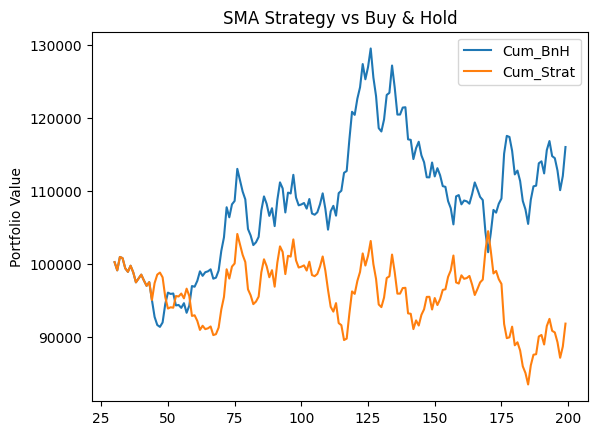

Win Rate: 52.35%
Profit Factor: 0.96


In [ ]:
# Generate 200 days price data
eps = np.random.normal(0.001, 0.018, 200)
p_200 = 1000 * np.cumprod(1 + eps)
df_sma = pd.DataFrame({'Price': p_200})

# a) SMA Crossover
df_sma['SMA_10'] = df_sma['Price'].rolling(10).mean()
df_sma['SMA_30'] = df_sma['Price'].rolling(30).mean()
df_sma.dropna(inplace=True)

# +1 if 10SMA > 30SMA, else -1
df_sma['Signal'] = np.where(df_sma['SMA_10'] > df_sma['SMA_30'], 1, -1)

# b) Simulate strategy
df_sma['Returns'] = df_sma['Price'].pct_change()
df_sma['Strategy_Returns'] = df_sma['Signal'].shift(1) * df_sma['Returns']

df_sma['Cum_BnH'] = (1 + df_sma['Returns']).cumprod() * 100000
df_sma['Cum_Strat'] = (1 + df_sma['Strategy_Returns']).cumprod() * 100000

df_sma[['Cum_BnH', 'Cum_Strat']].plot(title='SMA Strategy vs Buy & Hold')
plt.ylabel('Portfolio Value')
plt.show()

# c) Win Rate and Profit Factor
trades = df_sma['Strategy_Returns'].dropna()
winning_trades = len(trades[trades > 0])
total_active_trades = len(trades[trades != 0]) # Exclude zero return days
win_rate = winning_trades / total_active_trades

gross_profit = trades[trades > 0].sum()
gross_loss = abs(trades[trades < 0].sum())
profit_factor = gross_profit / gross_loss

print(f"Win Rate: {win_rate*100:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
# A Profit Factor > 1 just means gross profits > gross losses. 
# It does NOT guarantee a good strategy because it ignores the frequency of trades and total capital required.

### Problem 5: Feature Engineering

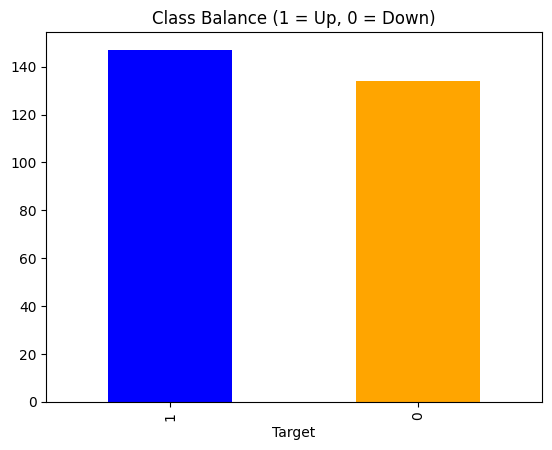

Features scaled successfully.


In [ ]:
# Generate 300 days price data
eps300 = np.random.normal(0.001, 0.018, 300)
p_300 = 500 * np.cumprod(1 + eps300)
df_ml = pd.DataFrame({'Price': p_300})

# a) Features
df_ml['Return_1d'] = df_ml['Price'].pct_change()
df_ml['SMA_5'] = df_ml['Price'].rolling(5).mean()
df_ml['SMA_20'] = df_ml['Price'].rolling(20).mean()
df_ml['Volatility_10'] = df_ml['Return_1d'].rolling(10).std()
df_ml['Momentum_5'] = df_ml['Price'] - df_ml['Price'].shift(5)
df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

# b) Binary Target
df_ml['Target'] = np.where(df_ml['Return_1d'].shift(-1) > 0, 1, 0)
df_ml.dropna(inplace=True) # drop last row which will have NaN target

df_ml['Target'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Class Balance (1 = Up, 0 = Down)')
plt.show()

# c) Min-Max Scaling
features = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
for col in features:
    min_val = df_ml[col].min()
    max_val = df_ml[col].max()
    df_ml[col] = (df_ml[col] - min_val) / (max_val - min_val)

print("Features scaled successfully.")
# Scaling is critical for KNN because KNN uses Euclidean distance. If one feature (like SMA) has values in the 500s 
# and another feature (like Return) has values around 0.01, the SMA distance will completely dominate the calculation.

### Problem 6: KNN From Scratch

Accuracy for k=3: 0.40
Accuracy for k=5: 0.44
Accuracy for k=7: 0.39
Accuracy for k=11: 0.42
Accuracy for k=15: 0.42


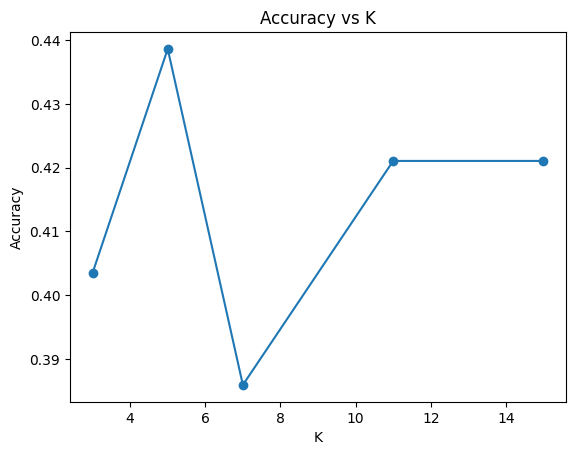


Best k: 5
Precision: 0.52
Recall: 0.39


In [ ]:
# a) Implement Euclidean and Predict
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        k_indices = np.argsort(distances)[:k]
        k_labels = [y_train[i] for i in k_indices]
        majority = max(set(k_labels), key=k_labels.count)
        predictions.append(majority)
    return np.array(predictions)

# Prepare data 80/20 split
split_idx = int(len(df_ml) * 0.8)
X = df_ml[features].values
y = df_ml['Target'].values

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# b) Test k values
ks = [3, 5, 7, 11, 15]
accuracies = []

for k in ks:
    preds = knn_predict(X_train, y_train, X_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"Accuracy for k={k}: {acc:.2f}")

plt.plot(ks, accuracies, marker='o')
plt.title('Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

# c) Confusion Matrix for best k
best_k = ks[np.argmax(accuracies)]
preds_best = knn_predict(X_train, y_train, X_test, best_k)

TP = np.sum((preds_best == 1) & (y_test == 1))
FP = np.sum((preds_best == 1) & (y_test == 0))
FN = np.sum((preds_best == 0) & (y_test == 1))
TN = np.sum((preds_best == 0) & (y_test == 0))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"\nBest k: {best_k}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
# When false positive trades are costly (meaning taking a trade and losing money), Precision is more important.
# Precision guarantees that when the model says 'Buy', it is actually right.

### Problem 7: Linear Regression from Scratch

Learned Coefficients (Normal Equation): [ 0.54789266 -0.03756411 -0.03312997 -0.0582059   0.06237467 -0.05636431]
MSE: 0.037185
R2 Score: -0.0192


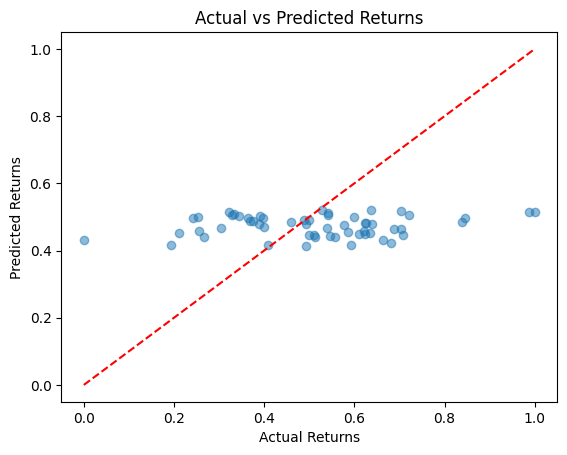

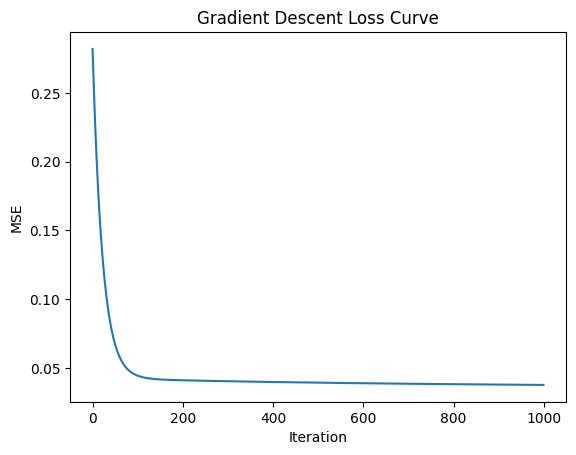

Learned Coefficients (Gradient Descent): [0.31093986 0.09160657 0.01565957 0.02543585 0.13627845 0.07764632]


In [7]:
# Continuous target
df_ml['Target_Return'] = df_ml['Return_1d'].shift(-1)
y_reg = df_ml['Target_Return'].fillna(0).values # safe fill for continuous

y_reg_train, y_reg_test = y_reg[:split_idx], y_reg[split_idx:]

# a) Normal Equation
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# beta = (X^T X)^-1 X^T y
beta = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_reg_train
print("Learned Coefficients (Normal Equation):", beta)

# b) Predictions and Metrics
y_pred = X_test_bias @ beta
mse = np.mean((y_reg_test - y_pred)**2)
sst = np.sum((y_reg_test - np.mean(y_reg_test))**2)
ssr = np.sum((y_reg_test - y_pred)**2)
r2 = 1 - (ssr / sst)

print(f"MSE: {mse:.6f}")
print(f"R2 Score: {r2:.4f}")

plt.scatter(y_reg_test, y_pred, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Actual vs Predicted Returns')
plt.show()

# c) Gradient Descent
beta_gd = np.zeros(X_train_bias.shape[1])
eta = 0.01
n = len(y_reg_train)
losses = []

for _ in range(1000):
    predictions = X_train_bias @ beta_gd
    error = predictions - y_reg_train
    gradient = (1/n) * X_train_bias.T @ error
    beta_gd = beta_gd - eta * gradient
    losses.append(np.mean(error**2))

plt.plot(losses)
plt.title('Gradient Descent Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.show()
print("Learned Coefficients (Gradient Descent):", beta_gd)

### Problem 8: Portfolio Allocation with Linear Regression

Sample weights (Day 1): [0.23092142 0.23540851 0.25812573 0.27554434]
Weights sum to: 0.9999999999999998


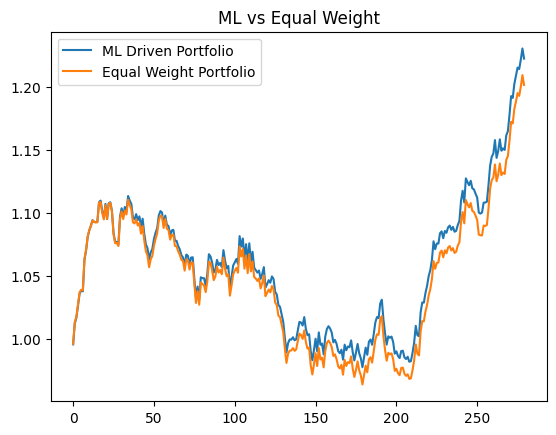

In [10]:
# Simulating the 4 assets over 300 days to allow for 20-day SMA calculation.
np.random.seed(0)
sim_returns_4 = np.random.normal(0.001, 0.015, (300, 4))
prices_4 = 1000 * np.cumprod(1 + sim_returns_4, axis=0)

# Fast feature engineering & prediction function
def predict_asset_returns(prices_array, beta_weights):
    df = pd.DataFrame({'Price': prices_array})
    df['Return_1d'] = df['Price'].pct_change()
    df['SMA_5'] = df['Price'].rolling(5).mean()
    df['SMA_20'] = df['Price'].rolling(20).mean()
    df['Volatility_10'] = df['Return_1d'].rolling(10).std()
    df['Momentum_5'] = df['Price'] - df['Price'].shift(5)
    df.dropna(inplace=True)
    
    # Scale using the previous Min-Max approach
    for col in features:
        min_val, max_val = df[col].min(), df[col].max()
        df[col] = (df[col] - min_val) / (max_val - min_val) if max_val != min_val else 0
        
    X_test_asset = df[features].values
    X_test_asset_bias = np.c_[np.ones(X_test_asset.shape[0]), X_test_asset]
    return X_test_asset_bias @ beta_weights # Predict all remaining days

predictions = []
for i in range(4):
    pred = predict_asset_returns(prices_4[:, i], beta)
    predictions.append(pred)
predictions = np.array(predictions).T

# b) Assign weights based on predictions
def calc_weights(preds):
    pos_preds = np.maximum(preds, 0)
    sum_preds = np.sum(pos_preds, axis=1, keepdims=True)
    # Avoid divide by zero if all predictions are negative
    weights = np.where(sum_preds > 0, pos_preds / sum_preds, 0.25) 
    return weights

ml_weights = calc_weights(predictions)
print("Sample weights (Day 1):", ml_weights[0])
print("Weights sum to:", np.sum(ml_weights[0]))

# c) Backtest
# Get actual returns starting from day 20
actual_returns = sim_returns_4[20:] 

# drop the last weight because we don't have day 301's return to test it against
ml_weights_aligned = ml_weights[:-1]

# Now shapes will be (280, 4) and (280, 4)
ml_port_returns = np.sum(ml_weights_aligned * actual_returns, axis=1)
eq_port_returns = np.sum(0.25 * actual_returns, axis=1)

ml_cum = np.cumprod(1 + ml_port_returns)
eq_cum = np.cumprod(1 + eq_port_returns)

plt.plot(ml_cum, label='ML Driven Portfolio')
plt.plot(eq_cum, label='Equal Weight Portfolio')
plt.legend()
plt.title('ML vs Equal Weight')
plt.show()
# A major limitation is that Linear Regression treats large positive errors and large negative errors equally. 
# In trading, being completely wrong on direction is disastrous, but LR cares more about magnitude.

### Problem 9: Model Comparison & CV

In [9]:
# a) k-Fold CV (k=5)
k_folds = 5
fold_size = len(X_train) // k_folds
cv_results = []

for k_knn in [3, 7, 11]:
    fold_accs = []
    for i in range(k_folds):
        start = i * fold_size
        end = start + fold_size if i != k_folds - 1 else len(X_train)
        
        val_X = X_train[start:end]
        val_y = y_train[start:end]
        
        train_X = np.concatenate([X_train[:start], X_train[end:]])
        train_y = np.concatenate([y_train[:start], y_train[end:]])
        
        preds = knn_predict(train_X, train_y, val_X, k_knn)
        fold_accs.append(np.mean(preds == val_y))
        
    cv_results.append({
        'K': k_knn, 
        'Mean Acc': np.mean(fold_accs), 
        'Std': np.std(fold_accs)
    })

for res in cv_results:
    print(f"KNN (k={res['K']}): Mean Acc = {res['Mean Acc']:.4f}, Std = {res['Std']:.4f}")

# b) Summary DataFrame
summary_df = pd.DataFrame({
    'Model': ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R2': [max([r['Mean Acc'] for r in cv_results]), r2],
    'MSE/N.A.': ['N/A', mse],
    'Best Param': [f"k={best_k}", "Normal Equation"]
})
print("\nModel Summary:\n", summary_df)

# c) Deployment strategy
# Based on the table, KNN is likely safer. Linear Regression produces extremely low R2 scores on financial 
# returns because stock returns are largely noise. KNN predicting a simple binary direction is a slightly easier 
# task for the math to handle.

# Deployment Risks:
# 1. Look-ahead bias: Accidentally using tomorrow's high/low price to calculate today's indicators.
# 2. Overfitting: The model memorizes past noise perfectly but blows up on unseen future data.

KNN (k=3): Mean Acc = 0.5371, Std = 0.0575
KNN (k=7): Mean Acc = 0.5500, Std = 0.0391
KNN (k=11): Mean Acc = 0.5242, Std = 0.0779

Model Summary:
                Model  Accuracy/R2  MSE/N.A.       Best Param
0     KNN Classifier     0.550000       N/A              k=5
1  Linear Regression    -0.019191  0.037185  Normal Equation
